In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import accuracy_score, roc_auc_score, mean_absolute_error

import yaml

import dataset_Oct22

In [2]:
OUTPUT_DIR = pathlib.Path("../output/ordinal_Oct22_models")
DATASET_CSV = pathlib.Path("../output/ordinal_Oct22_sequences_with_dca_score.csv")

In [3]:
ds = dataset_Oct22.Oct22DataSet(DATASET_CSV)
test_labels = ds.get_test_dataset().response.to_numpy()

In [4]:
# read in all the data from the output directory
model_info = {}
for filename in OUTPUT_DIR.glob("*.yml"):
    #print(filename)
    uuid = filename.stem
    with open(filename) as fh:
        mc = yaml.safe_load(fh)
    probs = np.loadtxt(OUTPUT_DIR / f"{uuid}.probs.txt")
    preds = np.loadtxt(OUTPUT_DIR / f"{uuid}.preds.txt")
    model_info[uuid] = {'config':mc, 'probs':probs, 'preds':preds}

In [5]:
test_labels_multiclass = np.eye(4)[test_labels]
test_labels_binary = np.eye(2)[test_labels.astype(bool).astype(int)]

In [6]:
model_extract = []
# extract info that needs to be plotted
for name, md in model_info.items():
    mc = md["config"]
    probs = md["probs"]
    preds = md["preds"]
    target = mc["target"]
    me =  {
            'model_name': mc["model_name"],
            'uuid' : mc["uuid"],
            'intercept': mc['design_matrix']["intercept"],
            'encoding': mc['design_matrix']["encoding"],
            'dca': mc['design_matrix']["dca"],
            'multilibrary': mc['design_matrix']["multilibrary"],
            'target': target,
            'accuracy': accuracy_score(test_labels, preds),
        }
    #test_label_indicators = test_labels_multiclass
    roc_test_labels = test_labels_multiclass.argmax(axis=1)
    if target == "binary":
        # make one dimensional arrays
        #test_label_indicators = test_labels.astype(bool).astype(int)
        roc_test_labels = test_labels_binary.argmax(axis=1)
        probs = probs[0, :]
    me["mae"] = mean_absolute_error(roc_test_labels, preds)
    me["auc_ovr"] = roc_auc_score(roc_test_labels, probs, multi_class='ovr', average="micro")
    me["auc_ovo"] = roc_auc_score(roc_test_labels, probs, multi_class='ovo')
    me["single_pred"] = (len(np.unique(preds)) <= 1)
        
    model_extract.append(me)
model_extract_df = pd.DataFrame(model_extract)
model_extract_df.round(2)

,model_name,uuid,intercept,encoding,dca,multilibrary,target,accuracy,mae,auc_ovr,auc_ovo,single_pred
0,SklearnRidgeClassifier,049830f8,False,one-hot,False,False,binary,0.52,0.32,0.35,0.35,False
1,SklearnRidgeClassifier,07df498c,False,one-hot,False,False,multiclass,0.53,0.58,0.81,0.66,False
2,SklearnRidgeClassifier,4450b384,True,one-hot,False,False,binary,0.52,0.33,0.34,0.34,False
3,SklearnLogisticRegression,6d97d935,False,one-hot,False,False,multiclass,0.55,0.58,0.83,0.69,False
4,SklearnRidgeClassifier,890b899b,True,one-hot,False,False,multiclass,0.53,0.58,0.82,0.66,False
5,SklearnLogisticRegression,9a10c5e1,True,one-hot,False,False,multiclass,0.55,0.58,0.83,0.69,False
6,SklearnLogisticRegression,ae68d863,False,one-hot,False,False,binary,0.51,0.33,0.37,0.37,True
7,SklearnLogisticRegression,cfeb8a05,True,one-hot,False,False,binary,0.51,0.33,0.38,0.38,True
8,ESMFT,esmft,False,esmft,False,True,multiclass,0.32,0.92,0.58,0.66,False
9,MLPLightning,5a7103a1,False,one-hot,True,True,multiclass,0.51,0.52,0.82,0.69,True


In [7]:
target_binary_models_df = model_extract_df[model_extract_df.target == "binary"]
target_binary_models_df

,model_name,uuid,intercept,encoding,dca,multilibrary,target,accuracy,mae,auc_ovr,auc_ovo,single_pred
0,SklearnRidgeClassifier,049830f8,False,one-hot,False,False,binary,0.522613,0.321608,0.350861,0.350861,False
2,SklearnRidgeClassifier,4450b384,True,one-hot,False,False,binary,0.522613,0.331658,0.343628,0.343628,False
6,SklearnLogisticRegression,ae68d863,False,one-hot,False,False,binary,0.507538,0.326633,0.373020,0.373020,True
7,SklearnLogisticRegression,cfeb8a05,True,one-hot,False,False,binary,0.507538,0.326633,0.384845,0.384845,True


* Intercept doesn't matter as all the values are the same so let's drop it

In [8]:
target_binary_models_df = target_binary_models_df[target_binary_models_df.intercept == False]

In [9]:
target_binary_models_df_melt = pd.melt(target_binary_models_df, id_vars=["model_name"], value_vars=["accuracy", "mae", 
                                                               "auc_ovr", "auc_ovo", "single_pred" ])

In [10]:
target_binary_models_df_melt

,model_name,variable,value
0,SklearnRidgeClassifier,accuracy,0.522613
1,SklearnLogisticRegression,accuracy,0.507538
2,SklearnRidgeClassifier,mae,0.321608
3,SklearnLogisticRegression,mae,0.326633
4,SklearnRidgeClassifier,auc_ovr,0.350861
5,SklearnLogisticRegression,auc_ovr,0.37302
6,SklearnRidgeClassifier,auc_ovo,0.350861
7,SklearnLogisticRegression,auc_ovo,0.37302
8,SklearnRidgeClassifier,single_pred,False
9,SklearnLogisticRegression,single_pred,True


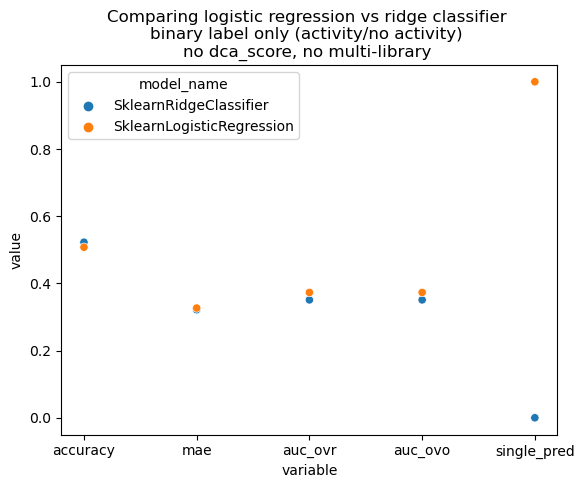

In [11]:
sns.scatterplot(target_binary_models_df_melt, x="variable", y="value", hue="model_name" )
plt.title("Comparing logistic regression vs ridge classifier \n"
          "binary label only (activity/no activity) \n"
          "no dca_score, no multi-library "
          )
pass

In [12]:
lighting_models_df = model_extract_df[model_extract_df.model_name.str.startswith("MLPLightning")]
lighting_models_df

,model_name,uuid,intercept,encoding,dca,multilibrary,target,accuracy,mae,auc_ovr,auc_ovo,single_pred
9,MLPLightning,5a7103a1,False,one-hot,True,True,multiclass,0.507538,0.517588,0.822185,0.688020,True
10,MLPLightning,140d9f93,False,one-hot,True,False,multiclass,0.447236,0.633166,0.748171,0.579557,False
11,MLPLightning,35804fd8,False,one-hot,False,False,multiclass,0.422111,0.638191,0.718576,0.559283,False


In [13]:
lighting_models_df_melt = pd.melt(lighting_models_df, id_vars=["uuid", "dca", "multilibrary"],
                                  value_vars=["accuracy", "mae", "auc_ovr", "auc_ovo", "single_pred"])
lighting_models_df_melt

,uuid,dca,multilibrary,variable,value
0,5a7103a1,True,True,accuracy,0.507538
1,140d9f93,True,False,accuracy,0.447236
2,35804fd8,False,False,accuracy,0.422111
3,5a7103a1,True,True,mae,0.517588
4,140d9f93,True,False,mae,0.633166
5,35804fd8,False,False,mae,0.638191
6,5a7103a1,True,True,auc_ovr,0.822185
7,140d9f93,True,False,auc_ovr,0.748171
8,35804fd8,False,False,auc_ovr,0.718576
9,5a7103a1,True,True,auc_ovo,0.68802


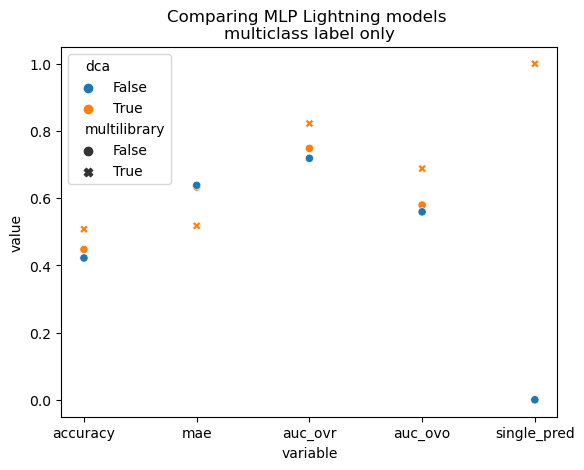

In [14]:
sns.scatterplot(lighting_models_df_melt, x="variable", y="value", hue="dca", style="multilibrary")
plt.title("Comparing MLP Lightning models \n"
          "multiclass label only"
         )
pass

In [15]:
target_multiclass_models_df = model_extract_df[(model_extract_df.target == "multiclass") &
                                               (model_extract_df.intercept == False)]
target_multiclass_models_df

,model_name,uuid,intercept,encoding,dca,multilibrary,target,accuracy,mae,auc_ovr,auc_ovo,single_pred
1,SklearnRidgeClassifier,07df498c,False,one-hot,False,False,multiclass,0.527638,0.582915,0.814474,0.657669,False
3,SklearnLogisticRegression,6d97d935,False,one-hot,False,False,multiclass,0.547739,0.577889,0.830383,0.688458,False
8,ESMFT,esmft,False,esmft,False,True,multiclass,0.316583,0.919598,0.578437,0.659425,False
9,MLPLightning,5a7103a1,False,one-hot,True,True,multiclass,0.507538,0.517588,0.822185,0.688020,True
10,MLPLightning,140d9f93,False,one-hot,True,False,multiclass,0.447236,0.633166,0.748171,0.579557,False
11,MLPLightning,35804fd8,False,one-hot,False,False,multiclass,0.422111,0.638191,0.718576,0.559283,False


In [16]:
target_multiclass_models_df_melt = pd.melt(target_multiclass_models_df, 
                                      id_vars=["uuid", "model_name", "dca", "multilibrary"],
                                      value_vars=["accuracy", "mae", "auc_ovr", "auc_ovo", "single_pred"])
target_multiclass_models_df_melt

,uuid,model_name,dca,multilibrary,variable,value
0,07df498c,SklearnRidgeClassifier,False,False,accuracy,0.527638
1,6d97d935,SklearnLogisticRegression,False,False,accuracy,0.547739
2,esmft,ESMFT,False,True,accuracy,0.316583
3,5a7103a1,MLPLightning,True,True,accuracy,0.507538
4,140d9f93,MLPLightning,True,False,accuracy,0.447236
5,35804fd8,MLPLightning,False,False,accuracy,0.422111
6,07df498c,SklearnRidgeClassifier,False,False,mae,0.582915
7,6d97d935,SklearnLogisticRegression,False,False,mae,0.577889
8,esmft,ESMFT,False,True,mae,0.919598
9,5a7103a1,MLPLightning,True,True,mae,0.517588


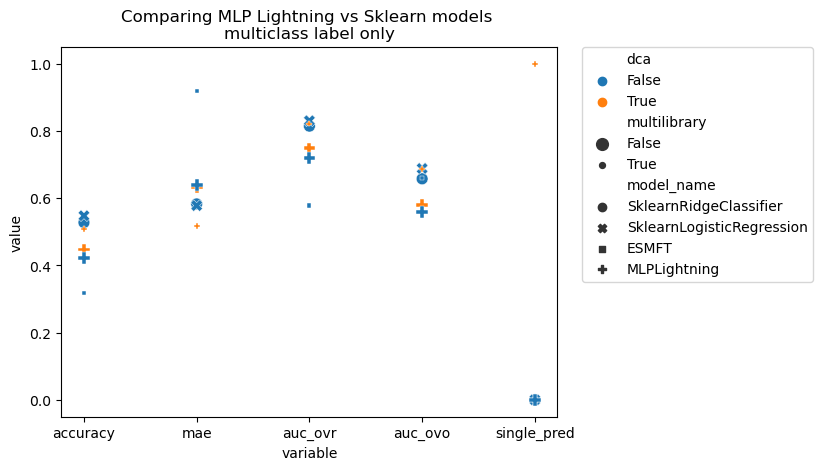

In [17]:
sns.scatterplot(target_multiclass_models_df_melt, x="variable", y="value", hue="dca", 
                style="model_name", size="multilibrary")
plt.title("Comparing MLP Lightning vs Sklearn models \n"
          "multiclass label only"
         )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
pass